# Model selection and the final test evaluation

Notebooks 03 to 07 each estimated one model's performance by nested cross-validation, using the training set only. None of them opened the test set.

This notebook does two things, in this order:

1. **Select.** Rank the five models on their nested CV score and pick a winner. This step uses training-set evidence only.
2. **Evaluate once.** Refit the winner on the full training set and score it on the test set a single time, at the threshold that was already chosen from out-of-fold predictions.

Nothing is tuned after the test set is opened. The order matters: because the winner is chosen before the test set is read, the test score is an estimate of that model's performance rather than the maximum of five test scores.

In [1]:
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay,
                             average_precision_score, roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score)

palette = ['#2B5C8F', '#E05A47']

## 1. The leaderboard

In [2]:
slugs = ['logistic_regression', 'decision_tree', 'random_forest', 'xgboost', 'neural_network']
board = pd.concat([pd.read_csv(f'../../../reports/results/{s}.csv') for s in slugs], ignore_index=True)
board = board.sort_values('nested_cv_pr_auc_mean', ascending=False).reset_index(drop=True)

board[['model', 'nested_cv_pr_auc_mean', 'nested_cv_pr_auc_std', 'inner_cv_pr_auc',
       'threshold', 'oof_f1_at_threshold', 'nested_seconds']].round(4)

,model,nested_cv_pr_auc_mean,nested_cv_pr_auc_std,inner_cv_pr_auc,threshold,oof_f1_at_threshold,nested_seconds
0,XGBoost,0.7612,0.0090,0.7602,0.3352,0.6982,97.0389
1,Random Forest,0.7548,0.0079,0.7532,0.3476,0.6955,1121.2674
2,Neural Network,0.7426,0.0111,0.7431,0.2988,0.6813,52.0370
3,Decision Tree,0.7079,0.0102,0.7064,0.3487,0.6605,23.8920
4,Logistic Regression,0.6470,0.0095,0.6464,0.3033,0.6269,15.2871


### Is 0.7612 good? The floor says what it is measured against

A PR-AUC of 0.7612 means nothing on its own. The number only becomes readable next to the score of a
model that has learned nothing at all, so that is computed here on the same five outer folds, with the
same metric, before the ranking above is interpreted.

`DummyClassifier(strategy='prior')` always returns the training cancellation rate as its probability,
for every booking. It cannot separate anything, and its average precision is the positive prevalence -
the score any real model has to beat before it has done any work.

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

train = pd.read_csv('../../data/processed/train.csv', dtype={'agent': str})
X_train, y_train = train.drop(columns=['is_canceled']), train['is_canceled']

# the same five outer folds every model in 03-07 was scored on
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy='prior')
dummy_ap = cross_val_score(dummy, X_train, y_train, cv=outer_cv, scoring='average_precision')
dummy_roc = cross_val_score(dummy, X_train, y_train, cv=outer_cv, scoring='roc_auc')
dummy_acc = cross_val_score(DummyClassifier(strategy='most_frequent'), X_train, y_train,
                            cv=outer_cv, scoring='accuracy')

print(f'positive prevalence in training: {y_train.mean():.4f}')
print(f'dummy PR-AUC:   {dummy_ap.mean():.4f} +/- {dummy_ap.std():.4f}')
print(f'dummy ROC-AUC:  {dummy_roc.mean():.4f}')
print(f'dummy accuracy: {dummy_acc.mean():.4f}   <- always answering "not cancelled"')

floor = dummy_ap.mean()
best = board.iloc[0]
print(f"\n{best['model']} PR-AUC {best['nested_cv_pr_auc_mean']:.4f} is "
      f"{best['nested_cv_pr_auc_mean'] / floor:.2f}x the floor "
      f"({best['nested_cv_pr_auc_mean'] - floor:+.4f} absolute)")

positive prevalence in training: 0.2775
dummy PR-AUC:   0.2775 +/- 0.0000
dummy ROC-AUC:  0.5000
dummy accuracy: 0.7225   <- always answering "not cancelled"

XGBoost PR-AUC 0.7612 is 2.74x the floor (+0.4837 absolute)


Three things to read off this.

**The floor is 0.2775, and it is exactly the cancellation rate.** That is not a coincidence: a model
that gives every booking the same score ranks them arbitrarily, so the fraction of cancellations among
the top *k* is the overall rate no matter where the cut is drawn. Average precision for a constant
predictor is always the prevalence, which makes it a floor you can state in advance rather than one
you have to discover.

**Every model beats it, and the ranking is not close to the floor.** Even Logistic Regression at
0.6470 is more than twice the floor, so no model in the table is failing. The interesting comparison
is between models, not against zero.

**The accuracy column is the warning.** Always answering "not cancelled" scores **72.25% accuracy**
while being useless - it never identifies a single cancellation. XGBoost reaches 81.87% accuracy on
the test set, which sounds like a modest 9.6-point improvement and badly undersells it. This is why
this project ranks on average precision and reports recall on the cancelled class beside it, and why
accuracy appears in the final table only as a secondary figure.

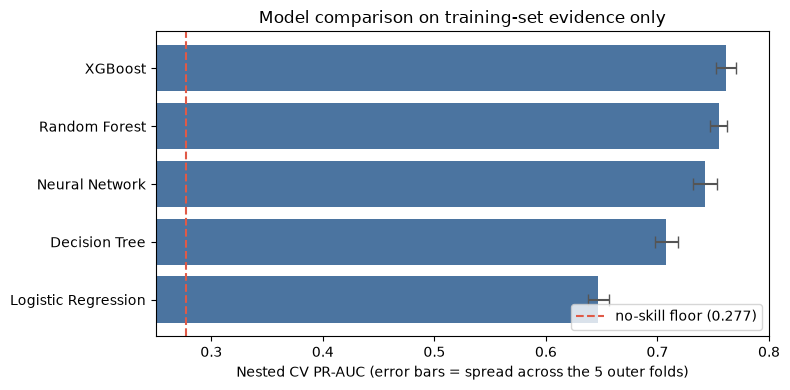

In [4]:
plt.figure(figsize=(8, 4))
plt.barh(board['model'][::-1], board['nested_cv_pr_auc_mean'][::-1],
         xerr=board['nested_cv_pr_auc_std'][::-1], color=palette[0], alpha=0.85,
         error_kw={'ecolor': '#555', 'capsize': 4})
plt.axvline(floor, color=palette[1], linestyle='--',
            label=f'no-skill floor ({floor:.3f})')
plt.legend(loc='lower right')
plt.xlabel('Nested CV PR-AUC (error bars = spread across the 5 outer folds)')
plt.title('Model comparison on training-set evidence only')
plt.xlim(0.25, 0.8)
plt.tight_layout()
plt.show()

In [5]:
# the gap between the top two, measured against the fold-to-fold noise
winner_row, runner_row = board.iloc[0], board.iloc[1]
gap = winner_row['nested_cv_pr_auc_mean'] - runner_row['nested_cv_pr_auc_mean']
floor = winner_row['nested_cv_pr_auc_std']

print(f"winner:     {winner_row['model']}  {winner_row['nested_cv_pr_auc_mean']:.4f} "
      f"+/- {winner_row['nested_cv_pr_auc_std']:.4f}")
print(f"runner-up:  {runner_row['model']}  {runner_row['nested_cv_pr_auc_mean']:.4f} "
      f"+/- {runner_row['nested_cv_pr_auc_std']:.4f}")
print(f'gap: {gap:.4f}   winner fold std: {floor:.4f}')
print('gap clears the noise floor:', bool(gap > floor))

# also record how optimistic the inner-CV score was, per model
board['optimism'] = board['inner_cv_pr_auc'] - board['nested_cv_pr_auc_mean']
board[['model', 'inner_cv_pr_auc', 'nested_cv_pr_auc_mean', 'optimism']].round(4)

winner:     XGBoost  0.7612 +/- 0.0090
runner-up:  Random Forest  0.7548 +/- 0.0079
gap: 0.0064   winner fold std: 0.0090
gap clears the noise floor: False


,model,inner_cv_pr_auc,nested_cv_pr_auc_mean,optimism
0,XGBoost,0.7602,0.7612,-0.0010
1,Random Forest,0.7532,0.7548,-0.0016
2,Neural Network,0.7431,0.7426,0.0005
3,Decision Tree,0.7064,0.7079,-0.0015
4,Logistic Regression,0.6464,0.6470,-0.0006


`optimism` is the gap between what the hyperparameter search reported for its own best setting and what the nested loop measured. It is the size of the bias that reporting `best_score_` would have introduced for each model — the reason this project switched to nested CV.

## 2. Rebuild the winning model

In [6]:
ESTIMATORS = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree':       (DecisionTreeClassifier(random_state=42), False),
    'Random Forest':       (RandomForestClassifier(random_state=42, n_jobs=-1), False),
    'XGBoost':             (XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss',
                                          importance_type='gain'), False),
    'Neural Network':      (MLPClassifier(random_state=42, max_iter=60, early_stopping=True,
                                          n_iter_no_change=5, validation_fraction=0.1), True),
}

winner = winner_row['model']
threshold = float(winner_row['threshold'])
# the parameters the winner's own notebook selected, read back and parsed
best_params = {k: ast.literal_eval(v) for k, v in json.loads(winner_row['best_params']).items()}

print('winner:', winner)
print('parameters:', best_params)
print('threshold chosen out-of-fold in that notebook:', round(threshold, 4))

winner: XGBoost
parameters: {'model__n_estimators': 600, 'model__max_depth': 10, 'model__learning_rate': 0.05}
threshold chosen out-of-fold in that notebook: 0.3352


In [7]:
train = pd.read_csv('../../data/processed/train.csv', dtype={'agent': str})
X_train, y_train = train.drop(columns=['is_canceled']), train['is_canceled']

categorical_cols = X_train.select_dtypes(exclude='number').columns
numeric_cols = X_train.select_dtypes(include='number').columns

estimator, needs_scaling = ESTIMATORS[winner]
preprocess = ColumnTransformer([
    ('num', StandardScaler() if needs_scaling else 'passthrough', numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100), categorical_cols),
], verbose_feature_names_out=False)

final_model = Pipeline([('prep', preprocess), ('model', estimator)])
final_model.set_params(**best_params)
final_model.fit(X_train, y_train)     # fitted on the training set only
print('refitted on', X_train.shape[0], 'training rows')

refitted on 67975 training rows


## 3. Opening the test set

Everything above this point used `train.csv`. The next cell is the first time `test.csv` is read in the whole modelling sequence, and the model and threshold are already fixed.

In [8]:
test = pd.read_csv('../../data/processed/test.csv', dtype={'agent': str})
X_test, y_test = test.drop(columns=['is_canceled']), test['is_canceled']
print('test:', X_test.shape, ' cancellation rate:', round(y_test.mean(), 4))

test_proba = final_model.predict_proba(X_test)[:, 1]

rows = []
for name, thr in [('0.50 (default)', 0.5), (f'{threshold:.3f} (chosen out-of-fold)', threshold)]:
    pred = (test_proba >= thr).astype(int)
    rows.append({'threshold': name,
                 'pr_auc': average_precision_score(y_test, test_proba),
                 'roc_auc': roc_auc_score(y_test, test_proba),
                 'f1': f1_score(y_test, pred), 'recall': recall_score(y_test, pred),
                 'precision': precision_score(y_test, pred),
                 'accuracy': accuracy_score(y_test, pred)})
pd.DataFrame(rows).round(4)

test: (16994, 25)  cancellation rate: 0.2775


,threshold,pr_auc,roc_auc,f1,recall,precision,accuracy
0,0.50 (default),0.7698,0.8924,0.6733,0.6259,0.7285,0.8315
1,0.335 (chosen out-of-fold),0.7698,0.8924,0.7019,0.7692,0.6454,0.8187


               precision    recall  f1-score   support

Not cancelled      0.904     0.838     0.870     12279
    Cancelled      0.645     0.769     0.702      4715

     accuracy                          0.819     16994
    macro avg      0.775     0.803     0.786     16994
 weighted avg      0.832     0.819     0.823     16994



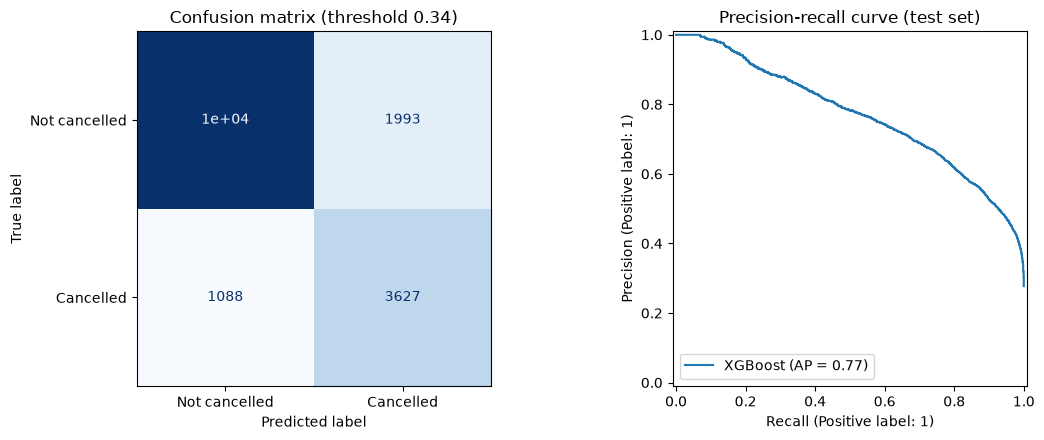

In [9]:
test_pred = (test_proba >= threshold).astype(int)
print(classification_report(y_test, test_pred, target_names=['Not cancelled', 'Cancelled'], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=['Not cancelled', 'Cancelled'],
                                        cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title(f'Confusion matrix (threshold {threshold:.2f})')
PrecisionRecallDisplay.from_predictions(y_test, test_proba, name=winner, ax=axes[1])
axes[1].set_title('Precision-recall curve (test set)')
plt.tight_layout()
plt.show()

In [10]:
# does the test score land where the nested CV said it would?
print(f"nested CV PR-AUC (training evidence): {winner_row['nested_cv_pr_auc_mean']:.4f} "
      f"+/- {winner_row['nested_cv_pr_auc_std']:.4f}")
print(f'test PR-AUC (held out):              {average_precision_score(y_test, test_proba):.4f}')
print(f"difference: {average_precision_score(y_test, test_proba) - winner_row['nested_cv_pr_auc_mean']:+.4f}")

nested CV PR-AUC (training evidence): 0.7612 +/- 0.0090
test PR-AUC (held out):              0.7698
difference: +0.0086


This is the check that the whole protocol exists to make possible. Because the test set played no part in choosing the model, the hyperparameters or the threshold, the two numbers above are a genuine out-of-sample comparison: the nested CV estimate was a prediction, and the test score is the outcome.

## 4. What drives the prediction

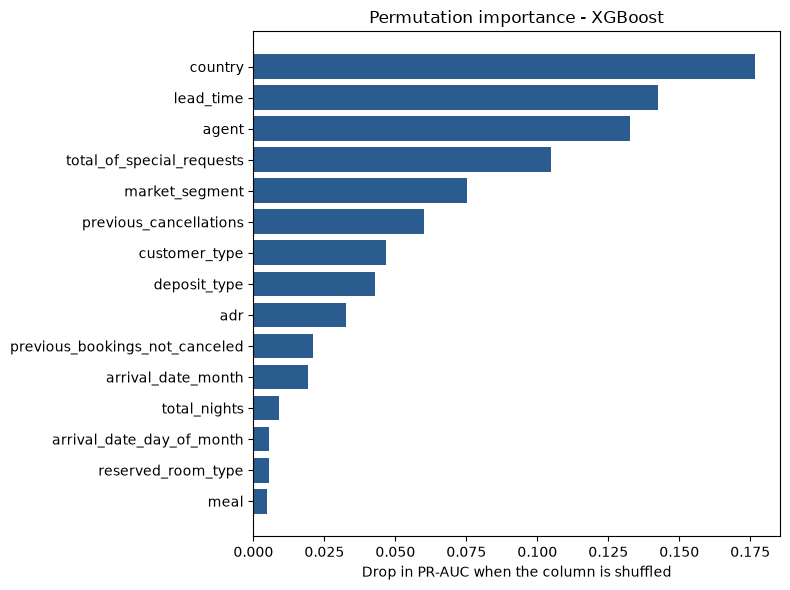

country                           0.1766
lead_time                         0.1424
agent                             0.1327
total_of_special_requests         0.1050
market_segment                    0.0754
previous_cancellations            0.0599
customer_type                     0.0469
deposit_type                      0.0429
adr                               0.0327
previous_bookings_not_canceled    0.0210
dtype: float64

In [11]:
# permutation importance: shuffle one column at a time and watch PR-AUC fall.
# This runs after the headline metric is recorded - it is interpretation, not selection.
perm = permutation_importance(final_model, X_test, y_test, scoring='average_precision',
                              n_repeats=5, random_state=42, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
top = importance.head(15).sort_values()
plt.barh(top.index, top.values, color=palette[0])
plt.xlabel('Drop in PR-AUC when the column is shuffled')
plt.title(f'Permutation importance - {winner}')
plt.tight_layout()
plt.show()

importance.head(10).round(4)

## 5. Which cancellations are missed?

In [12]:
cancelled = X_test[y_test == 1].assign(caught=test_pred[y_test == 1] == 1)
print('missed cancellations:', int((~cancelled['caught']).sum()), 'of', len(cancelled))
print('\nmedian lead time, missed vs caught:')
print(cancelled.groupby('caught')['lead_time'].median())
print('\nmarket segment share, missed vs caught:')
pd.crosstab(cancelled['market_segment'], cancelled['caught'], normalize='columns').round(3)

missed cancellations: 1088 of 4715

median lead time, missed vs caught:
caught
False    42.0
True     92.0
Name: lead_time, dtype: float64

market segment share, missed vs caught:


caught,False,True
market_segment,,
Aviation,0.005,0.002
Complementary,0.013,0.001
Corporate,0.054,0.012
Direct,0.209,0.038
Groups,0.018,0.060
Offline TA/TO,0.070,0.084
Online TA,0.631,0.804
Undefined,0.000,0.001


## 6. Save the final result

In [13]:
final = {
    'model': winner,
    'nested_cv_pr_auc_mean': winner_row['nested_cv_pr_auc_mean'],
    'nested_cv_pr_auc_std': winner_row['nested_cv_pr_auc_std'],
    'threshold': threshold,
    'test_pr_auc': average_precision_score(y_test, test_proba),
    'test_roc_auc': roc_auc_score(y_test, test_proba),
    'test_f1': f1_score(y_test, test_pred),
    'test_recall': recall_score(y_test, test_pred),
    'test_precision': precision_score(y_test, test_pred),
    'test_accuracy': accuracy_score(y_test, test_pred),
    'best_params': json.dumps({k: str(v) for k, v in best_params.items()}),
}
Path('../../reports/results').mkdir(parents=True, exist_ok=True)
pd.DataFrame([final]).round(4).to_csv('../../reports/results/final_model.csv', index=False)
board.round(4).to_csv('../../reports/results/leaderboard.csv', index=False)
pd.DataFrame([final]).round(4).T

,0
model,XGBoost
nested_cv_pr_auc_mean,0.7612
nested_cv_pr_auc_std,0.009
threshold,0.3352
test_pr_auc,0.7698
test_roc_auc,0.8924
test_f1,0.7019
test_recall,0.7692
test_precision,0.6454
test_accuracy,0.8187


## Conclusion

**Selected model: XGBoost**, at `{'model__n_estimators': '600', 'model__max_depth': '10', 'model__learning_rate': '0.05'}`, with a decision threshold of 0.3352 chosen from out-of-fold training predictions.

On the test set, read once and only after that choice was fixed, it reaches **PR-AUC 0.7698**, ROC-AUC 0.8924, and at the chosen threshold F1 0.7019 with recall 0.7692 and precision 0.6454. It catches 76.9% of cancellations at 64.5% precision.

**The test score landed +0.0086 from the nested CV estimate of 0.7612**, which is inside the 0.0090 fold-to-fold spread. Since the test set played no part in selecting the model, its hyperparameters or its threshold, that agreement is a real out-of-sample check rather than a restatement of something already fitted: the estimate was made first, and the outcome matched it.

**The margin over the runner-up is not significant.** XGBoost leads Random Forest by 0.0064 PR-AUC against a fold spread of 0.0090. The honest reading is that these two models are not distinguishable on this data, and XGBoost is preferred on secondary grounds — it evaluated in 97 s against 1121 s for Random Forest, roughly 12 times faster. One caveat belongs on the record: the two searches were not equally thorough, so a larger budget for either could move this gap.

The error analysis repeats what every model in this project has shown: the missed cancellations are the short-notice ones (median lead time 42 days against 92 for those caught). A booking cancelled a week before arrival looks, at the moment it was made, much like one that will be honoured.